# EDA with MEDCIC data

In [16]:
import os
import pydicom
import numpy as np
import zarr
import dask.array as da
import matplotlib.pyplot as plt
import glob
import pydicom
from ipywidgets import interact, IntSlider

import dicom_to_zarr

Convertion of dicom data.

In [9]:
# Define paths (please adjust if needed)
dicom_folder = 'MRI-Datasets/159277_B1/1/DICOM' 
zarr_file = 'MRI-Datasets/Converted_to_zarr/159277_B1.zarr'

# Make sure the folder exists before calling the function
if not os.path.exists(dicom_folder):
    os.makedirs(dicom_folder)
    print(f"Folder '{dicom_folder}' was created. Please fill it with your DICOM files.")
elif not os.listdir(dicom_folder):
    print(f"The folder '{dicom_folder}' is empty. Please add DICOM files to run the script.")
else:
    # Call the conversion function
    dicom_to_zarr.convert_dicom_to_zarr(dicom_folder, zarr_file)

Lese DICOM-Dateien aus: MRI-Datasets/159277_B1/1/DICOM
Stapele DICOM-Schichten zu einem 3D-Raum...
Extrahierte Metadaten: {'PixelSpacing': [0.9375, 0.9375], 'SliceThickness': 8.5, 'Rows': 512, 'Columns': 512, 'PatientID': 'MEDCIC_07_B1'}
Speichere Array der Größe (22, 512, 512) in MRI-Datasets/Converted_to_zarr/159277_B1.zarr...
Konvertierung abgeschlossen!


## Exploratory Data Analysis (EDA) of the Zarr File

In [10]:
try:
    z_array = zarr.open(zarr_file, mode='r')

    # Print metadata and array properties
    metadata = z_array.attrs['metadata']
    print(f"Zarr array successfully loaded.")
    print(f"Shape: {z_array.shape}")
    print(f"Dtype: {z_array.dtype}")
    print(f"Stored Metadata: {metadata}")
    
    DATA_LOADED = True
except FileNotFoundError:
    print(f"Error: '{zarr_file}' not found. Please ensure Part 1 ran successfully.")
    DATA_LOADED = False

Zarr array successfully loaded.
Shape: (22, 512, 512)
Dtype: int16
Stored Metadata: {'PixelSpacing': [0.9375, 0.9375], 'SliceThickness': 8.5, 'Rows': 512, 'Columns': 512, 'PatientID': 'MEDCIC_07_B1'}


In [ ]:
# Load the Zarr store into a Dask array
# This operation is lazy and loads no data
try:
    dask_array = da.from_zarr(zarr_file)
    DATA_LOADED = True
except FileNotFoundError:
    print(f"Error: Zarr file '{zarr_file}' not found. Make sure Part 1 was successful.")
    DATA_LOADED = False

In [18]:
dask_array

dask.array<from-zarr, shape=(22, 512, 512), dtype=int16, chunksize=(22, 128, 128), chunktype=numpy.ndarray>

interactive(children=(IntSlider(value=21, description='Slice:', max=21), Output()), _dom_classes=('widget-inte…

Visualization: Displaying Slices

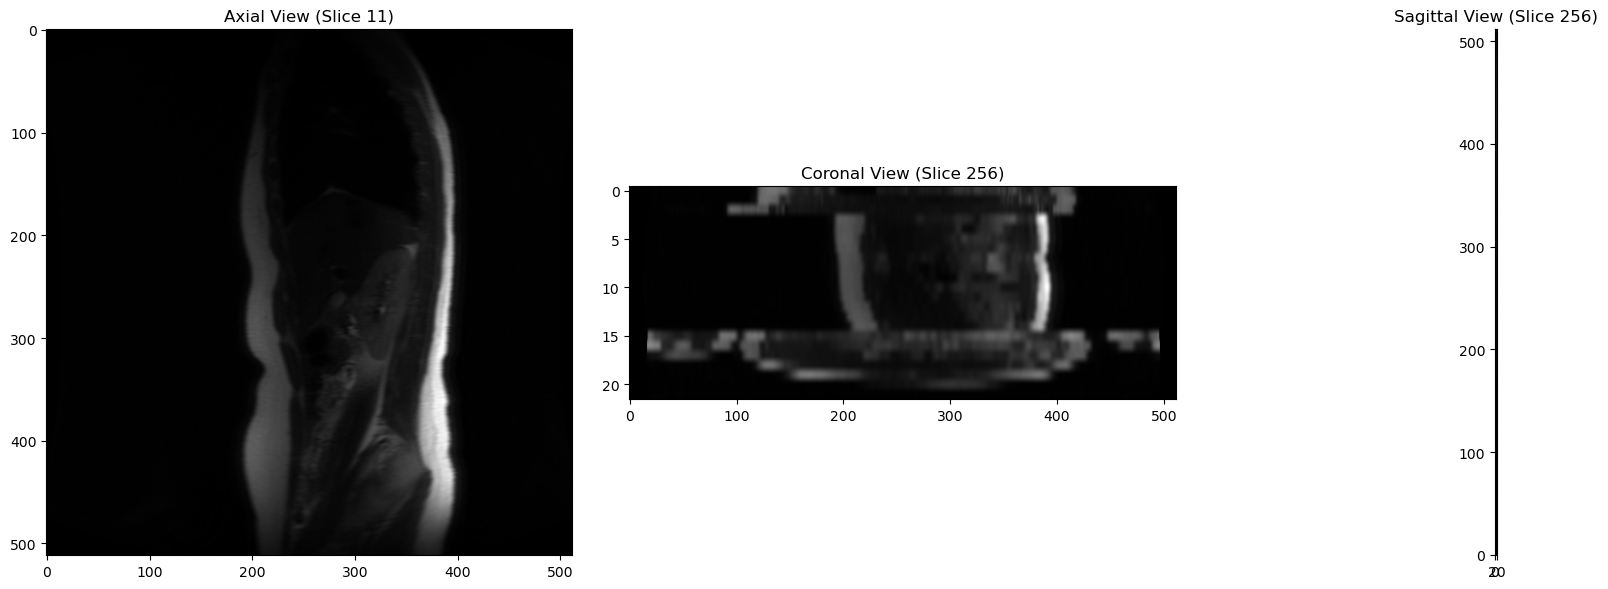

In [12]:
if DATA_LOADED:
    # Calculate indices for the middle slices
    z, y, x = z_array.shape
    mid_z, mid_y, mid_x = z // 2, y // 2, x // 2

    # Load data for the three views
    axial_slice = z_array[mid_z, :, :]
    sagittal_slice = z_array[:, :, mid_x]
    coronal_slice = z_array[:, mid_y, :]

    # Create plots
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    axes[0].imshow(axial_slice, cmap='gray', aspect=metadata['PixelSpacing'][0]/metadata['PixelSpacing'][1])
    axes[0].set_title(f'Axial View (Slice {mid_z})')

    axes[1].imshow(coronal_slice, cmap='gray', aspect=metadata['SliceThickness']/metadata['PixelSpacing'][0])
    axes[1].set_title(f'Coronal View (Slice {mid_y})')
    
    axes[2].imshow(sagittal_slice.T, cmap='gray', origin='lower', aspect=metadata['SliceThickness']/metadata['PixelSpacing'][1]) # Use .T for correct orientation
    axes[2].set_title(f'Sagittal View (Slice {mid_x})')

    plt.tight_layout()
    plt.show()

Calculating histogram for the first scan...


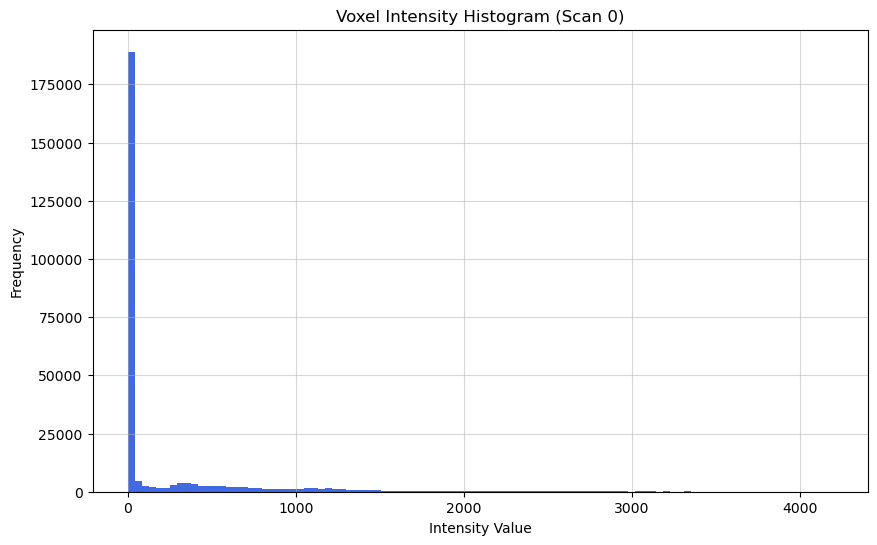

In [29]:
# Calculate histogram using Dask. This is still lazy.
# We select the first scan for this example
print("Calculating histogram for the first scan...")
first_scan_array = dask_array[0, :, :]

# Define histogram bins
bins = np.linspace(first_scan_array.min().compute(), first_scan_array.max().compute(), 101)

# Compute the histogram. This is where the actual computation happens.
counts, edges = da.histogram(first_scan_array, bins=bins)
hist_counts, hist_edges = counts.compute(), edges # .compute() to get results
# Plot the results
plt.figure(figsize=(10, 6))
plt.bar(hist_edges[:-1], hist_counts, width=np.diff(hist_edges), align='edge', color='royalblue')
plt.title('Voxel Intensity Histogram (Scan 0)')
plt.xlabel('Intensity Value')
plt.ylabel('Frequency')
plt.grid(True, alpha=0.5)
plt.show()